In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
path = []
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        path.append(os.path.join(dirname, filename))
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pima-indians-diabetes-database/diabetes.csv


# kNN Classifier
ML lab 6


**Yasir Ahmad**   
**22MIA1064**


In [2]:
df = pd.read_csv(path[0])
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.shape

(768, 9)

In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop('Outcome',axis=1)
y = df['Outcome']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3)

In [6]:
X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
137,0,93,60,25,92,28.7,0.532,22
1,1,85,66,29,0,26.6,0.351,31
30,5,109,75,26,0,36.0,0.546,60
145,0,102,75,23,0,0.0,0.572,21
449,0,120,74,18,63,30.5,0.285,26


In [7]:
y_train.head()

137    0
1      0
30     0
145    0
449    0
Name: Outcome, dtype: int64

## models

In [8]:
Train_acc = {'Euclidean':0,'Manhattan':0,'Minkowski':0}
Test_acc = {'Euclidean':0,'Manhattan':0,'Minkowski':0}

## metric = Euclidean

In [9]:
from sklearn.neighbors import KNeighborsClassifier

n = [i for i in range(1,11,2)]
train_acc = []
test_acc = []

for k in n:
    print(f"\nk = {k}")
    
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    print(knn)
    #Fit the model
    knn.fit(X_train, y_train)
    
    
    train=knn.score(X_train, y_train)
    print(f"Training accuracy {train}")
    #Compute accuracy on the training set
    train_acc.append(train)
    
    #Compute accuracy on the test set
    test=knn.score(X_test, y_test)
    print(f"Test accuracy {test}")
    test_acc.append(test)


k = 1
KNeighborsClassifier(metric='euclidean', n_neighbors=1)
Training accuracy 1.0
Test accuracy 0.6536796536796536

k = 3
KNeighborsClassifier(metric='euclidean', n_neighbors=3)
Training accuracy 0.8547486033519553
Test accuracy 0.6406926406926406

k = 5
KNeighborsClassifier(metric='euclidean')
Training accuracy 0.8156424581005587
Test accuracy 0.683982683982684

k = 7
KNeighborsClassifier(metric='euclidean', n_neighbors=7)
Training accuracy 0.8081936685288641
Test accuracy 0.7012987012987013

k = 9
KNeighborsClassifier(metric='euclidean', n_neighbors=9)
Training accuracy 0.7821229050279329
Test accuracy 0.7229437229437229


In [10]:
Train_acc['Euclidean'] = 0.845437616387337
Test_acc['Euclidean'] = 0.683982683982684

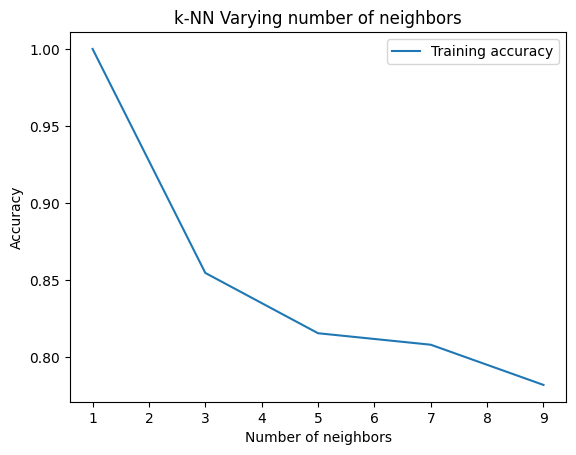

In [11]:
from matplotlib import pyplot as plt
#Generate plot
plt.title('k-NN Varying number of neighbors')
#plt.plot(n, test_acc, label='Testing Accuracy')
plt.plot(n, train_acc, label='Training accuracy')
plt.legend()
plt.xlabel('Number of neighbors')
plt.ylabel('Accuracy')
plt.show()

## metric = Manhattan

In [12]:
from sklearn.neighbors import KNeighborsClassifier

n = [i for i in range(1,11,2)]
train_acc = []
test_acc = []

for k in n:
    print(f"\nk = {k}")
    
    knn = KNeighborsClassifier(n_neighbors=k, metric="manhattan")
    print(knn)
    #Fit the model
    knn.fit(X_train, y_train)
    
    
    train=knn.score(X_train, y_train)
    print(f"Training accuracy {train}")
    #Compute accuracy on the training set
    train_acc.append(train)
    
    #Compute accuracy on the test set
    test=knn.score(X_test, y_test)
    print(f"Test accuracy {test}")
    test_acc.append(test)


k = 1
KNeighborsClassifier(metric='manhattan', n_neighbors=1)
Training accuracy 1.0
Test accuracy 0.6623376623376623

k = 3
KNeighborsClassifier(metric='manhattan', n_neighbors=3)
Training accuracy 0.8659217877094972
Test accuracy 0.645021645021645

k = 5
KNeighborsClassifier(metric='manhattan')
Training accuracy 0.8119180633147114
Test accuracy 0.70995670995671

k = 7
KNeighborsClassifier(metric='manhattan', n_neighbors=7)
Training accuracy 0.7895716945996276
Test accuracy 0.7186147186147186

k = 9
KNeighborsClassifier(metric='manhattan', n_neighbors=9)
Training accuracy 0.7839851024208566
Test accuracy 0.7532467532467533


In [13]:
Train_acc['Manhattan'] = 0.8305400372439479
Test_acc['Manhattan'] = 0.7056277056277056

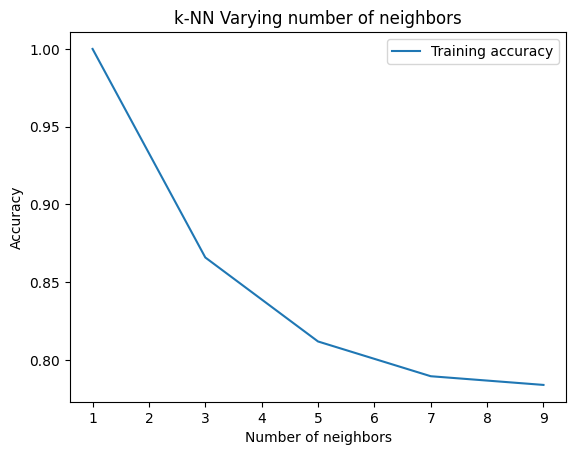

In [14]:
from matplotlib import pyplot as plt
#Generate plot
plt.title('k-NN Varying number of neighbors')
#plt.plot(n, test_acc, label='Testing Accuracy')
plt.plot(n, train_acc, label='Training accuracy')
plt.legend()
plt.xlabel('Number of neighbors')
plt.ylabel('Accuracy')
plt.show()

## metric = Minkowski

In [15]:
from sklearn.neighbors import KNeighborsClassifier

n = [i for i in range(1,11,2)]
train_acc = []
test_acc = []

for k in n:
    print(f"\nk = {k}")
    
    knn = KNeighborsClassifier(n_neighbors=k,metric="minkowski")
    
    print(knn)
    #Fit the model
    knn.fit(X_train, y_train)
    
    
    train=knn.score(X_train, y_train)
    print(f"Training accuracy {train}")
    #Compute accuracy on the training set
    train_acc.append(train)
    
    #Compute accuracy on the test set
    test=knn.score(X_test, y_test)
    print(f"Test accuracy {test}")
    test_acc.append(test)


k = 1
KNeighborsClassifier(n_neighbors=1)
Training accuracy 1.0
Test accuracy 0.6536796536796536

k = 3
KNeighborsClassifier(n_neighbors=3)
Training accuracy 0.8547486033519553
Test accuracy 0.6406926406926406

k = 5
KNeighborsClassifier()
Training accuracy 0.8156424581005587
Test accuracy 0.683982683982684

k = 7
KNeighborsClassifier(n_neighbors=7)
Training accuracy 0.8081936685288641
Test accuracy 0.7012987012987013

k = 9
KNeighborsClassifier(n_neighbors=9)
Training accuracy 0.7821229050279329
Test accuracy 0.7229437229437229


In [16]:
Train_acc["Minkowski"] = 0.845437616387337
Test_acc["Minkowski"] = 0.683982683982684

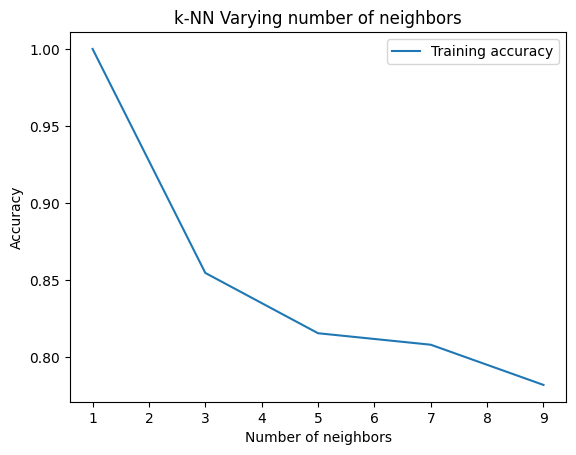

In [17]:
from matplotlib import pyplot as plt
#Generate plot
plt.title('k-NN Varying number of neighbors')
#plt.plot(n, test_acc, label='Testing Accuracy')
plt.plot(n, train_acc, label='Training accuracy')
plt.legend()
plt.xlabel('Number of neighbors')
plt.ylabel('Accuracy')
plt.show()

## Optimality

K = 3 elbow

In [18]:
print(f"test_acc: {Test_acc}")
print(f"train_acc: {Train_acc}")

test_acc: {'Euclidean': 0.683982683982684, 'Manhattan': 0.7056277056277056, 'Minkowski': 0.683982683982684}
train_acc: {'Euclidean': 0.845437616387337, 'Manhattan': 0.8305400372439479, 'Minkowski': 0.845437616387337}


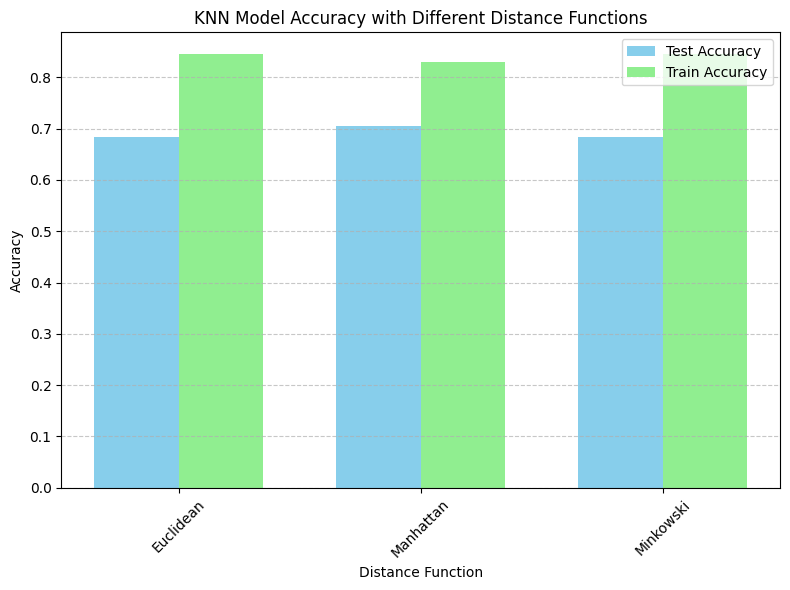

In [19]:
import matplotlib.pyplot as plt

test_acc= Test_acc
train_acc= Train_acc

# Create a bar plot
plt.figure(figsize=(8, 6))
x = ['Euclidean', 'Manhattan', 'Minkowski']  # Distance functions as x-axis labels
x_indices = range(len(x))  # X-axis positions for the bars

bar_width = 0.35  # Width of the bars

# Plot test accuracy
plt.bar([i - bar_width/2 for i in x_indices], test_acc.values(), width=bar_width, label='Test Accuracy', color='skyblue')

# Plot train accuracy
plt.bar([i + bar_width/2 for i in x_indices], train_acc.values(), width=bar_width, label='Train Accuracy', color='lightgreen')

# Set labels and title
plt.xlabel('Distance Function')
plt.ylabel('Accuracy')
plt.title('KNN Model Accuracy with Different Distance Functions')

# Add legend
plt.legend()

# Rotate x-axis labels for better readability
plt.xticks(ticks=x_indices, labels=x, rotation=45)

# Show the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Therefore optimal k = **3** and metric = manhattan

# Final Model

In [20]:
k = 3
print(f"\nk = {k}")

knn = KNeighborsClassifier(n_neighbors=k,metric="manhattan")

print(knn)
#Fit the model
knn.fit(X_train, y_train)


train=knn.score(X_train, y_train)
print(f"Training accuracy {train}")


#Compute accuracy on the test set
test=knn.score(X_test, y_test)
print(f"Test accuracy {test}")


k = 3
KNeighborsClassifier(metric='manhattan', n_neighbors=3)
Training accuracy 0.8659217877094972
Test accuracy 0.645021645021645


# kNN regressor

In [21]:
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Features and target
X = df.drop(columns=['SkinThickness'])  # Features
y = df['SkinThickness']  # Target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the KNN Regressor
knn = KNeighborsRegressor(n_neighbors=3)  # You can tune 'n_neighbors' for better results

# Train the model
knn.fit(X_train_scaled, y_train)

# Make predictions
y_pred = knn.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

# Display actual vs predicted values
print(f'Actual BloodPressure: {y_test.values}')
print(f'Predicted BloodPressure: {y_pred}')


Mean Squared Error: 272.53030303030295
R^2 Score: 0.14525375908984073
Actual BloodPressure: [33 32  0  0  0 32 18  0 29  0 27 31 27 18 26 40 32 28  0 26  0 29 54 27
 28 33 27 12 36 16 56  0 39  0  0 34 99 30 17  0 22  0 26  0  0 36 47 33
  0 32 22 34 43  0 17 28  0  0 32  0 32 27  7  7 31 54 22  0  0 49 42 19
  0 25  0 37  0 34 31  0  0 37 24 46 18 22 44 28 27 16 25  0  0  0 32 40
  0 28 29  0 43 29  0 35  0 42 34 39 31 31 23  0  0 46 30 32 38  0  0  0
  0 52 35 18  0 48  0 28  0 31  0 40  8 35 42  0  0  0 29 13 22  0  0 41
  0 31 22 10 40  0 30  0 38 40]
Predicted BloodPressure: [32.33333333  9.         24.66666667 18.         13.66666667 36.
 13.66666667  7.66666667 23.33333333  5.          8.66666667  5.
 27.         24.66666667 12.         32.         24.         20.66666667
  0.         40.66666667 10.         31.33333333 13.33333333 27.
 29.66666667  0.          0.         14.66666667 32.66666667 12.
 33.33333333  6.         36.          0.         13.         38.66666667
  9.666

In [23]:
from sklearn.metrics import mean_squared_error, r2_score

# Predict on training data
y_train_pred = knn.predict(X_train_scaled)

# Predict on test data
y_test_pred = knn.predict(X_test_scaled)

# Calculate MSE and R² for training data
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Calculate MSE and R² for test data
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Display the results
print(f"Training Data Metrics:")
print(f"  Mean Squared Error: {train_mse:.4f}")
print(f"  R² Score: {train_r2:.4f}\n")

print(f"Testing Data Metrics:")
print(f"  Mean Squared Error: {test_mse:.4f}")
print(f"  R² Score: {test_r2:.4f}")


Training Data Metrics:
  Mean Squared Error: 86.9622
  R² Score: 0.6343

Testing Data Metrics:
  Mean Squared Error: 272.5303
  R² Score: 0.1453


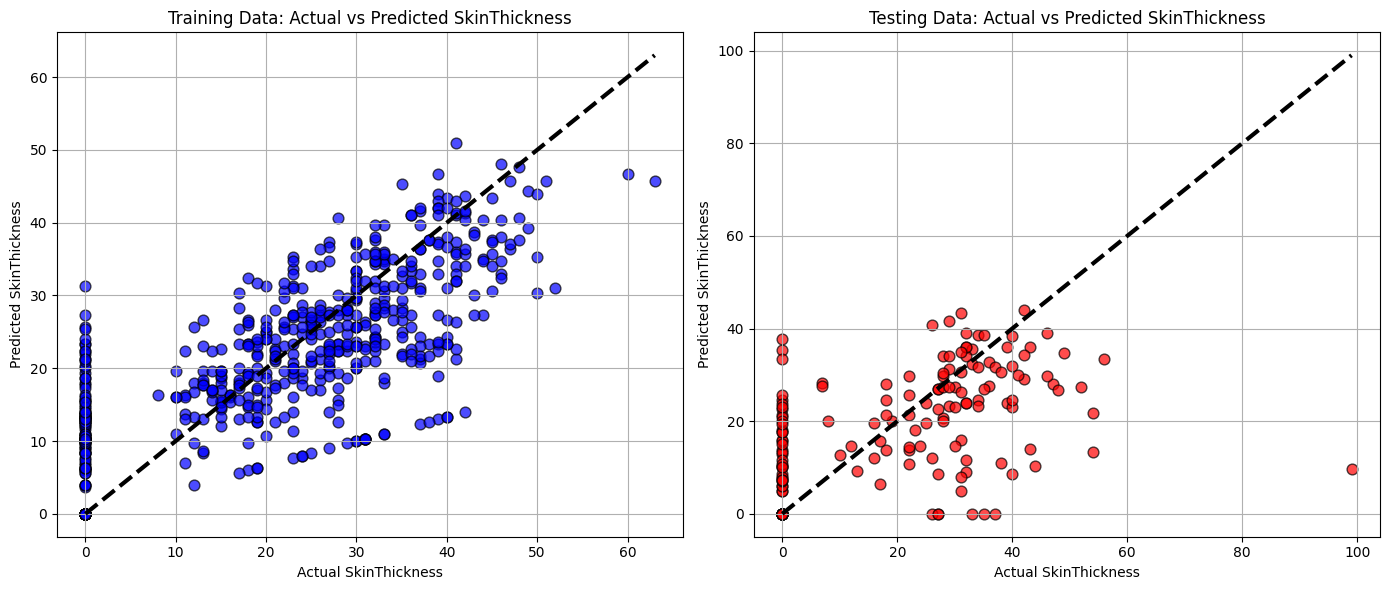

In [24]:
import matplotlib.pyplot as plt

# Create a figure with two subplots: one for training data, one for testing data
plt.figure(figsize=(14, 6))

# Training Data Plot
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, color='blue', edgecolor='k', alpha=0.7, s=60)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', lw=3)
plt.xlabel('Actual SkinThickness')
plt.ylabel('Predicted SkinThickness')
plt.title('Training Data: Actual vs Predicted SkinThickness')
plt.grid(True)

# Testing Data Plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, color='red', edgecolor='k', alpha=0.7, s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3)
plt.xlabel('Actual SkinThickness')
plt.ylabel('Predicted SkinThickness')
plt.title('Testing Data: Actual vs Predicted SkinThickness')
plt.grid(True)

plt.tight_layout()
plt.show()
